# _Numpy and pandas Project_

# __International T20 cricket performance analysis__

In [608]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [609]:
players = pd.read_csv("T20i Data set\players_info.csv")
batting = pd.read_csv("T20i Data set\T20i_Batting_Card.csv")
bowling = pd.read_csv("T20i Data set\T20i_Bowling_Card.csv")
matches = pd.read_csv("T20i Data set\T20i_Matches_Data.csv")
partnership = pd.read_csv("T20i Data set\T20i_Partnership_Card.csv")


<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\3781001016.py:1: SyntaxWarning: invalid escape sequence '\p'
  players = pd.read_csv("T20i Data set\players_info.csv")
C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\3781001016.py:2: SyntaxWarning: invalid escape sequence '\T'
  batting = pd.read_csv("T20i Data set\T20i_Batting_Card.csv")
C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\3781001016.py:3: SyntaxWarning: invalid escape sequence '\T'
  bowling = pd.read_csv("T20i Data set\T

__Analyze players_info.csv__

In [610]:
players.head()

,player_id,player_object_id,player_name,dob,dod,gender,batting_style,bowling_style,country_id,image_url,image_metadata
0,93957,1046619,Avinash Pai,24-01-1982,NaN,M,right-hand bat,right-arm offbreak,18.0,NaN,NaN
1,2182,51462,Sherwin Campbell,01-11-1970,NaN,M,right-hand bat,right-arm medium,4.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 326616, 'url': '/db/PICTURES/CMS/326600..."
2,48391,56194,Tamim Iqbal,20-03-1989,NaN,M,left-hand bat,NaN,25.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 303166, 'url': '/db/PICTURES/CMS/303100..."
3,2198,55935,Javed Omar,25-11-1976,NaN,M,right-hand bat,legbreak,25.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 302990, 'url': '/db/PICTURES/CMS/302900..."
4,52290,298438,Jason Roy,21-07-1990,NaN,M,right-hand bat,NaN,1.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 303963, 'url': '/db/PICTURES/CMS/303900..."


In [611]:
#   information of data
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6701 entries, 0 to 6700
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         6701 non-null   int64  
 1   player_object_id  6701 non-null   int64  
 2   player_name       6701 non-null   object 
 3   dob               6674 non-null   object 
 4   dod               1258 non-null   object 
 5   gender            6701 non-null   object 
 6   batting_style     6608 non-null   object 
 7   bowling_style     5547 non-null   object 
 8   country_id        6699 non-null   float64
 9   image_url         3753 non-null   object 
 10  image_metadata    3753 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 576.0+ KB


In [612]:
players.size

73711

In [613]:
#   Shape of the dataset
players.shape

(6701, 11)

In [614]:
#   Column names
players.columns


Index(['player_id', 'player_object_id', 'player_name', 'dob', 'dod', 'gender',
       'batting_style', 'bowling_style', 'country_id', 'image_url',
       'image_metadata'],
      dtype='object')

In [615]:
#   Data types
players.dtypes

player_id             int64
player_object_id      int64
player_name          object
dob                  object
dod                  object
gender               object
batting_style        object
bowling_style        object
country_id          float64
image_url            object
image_metadata       object
dtype: object

In [616]:
#   Check missing values
players.isnull().sum()

player_id              0
player_object_id       0
player_name            0
dob                   27
dod                 5443
gender                 0
batting_style         93
bowling_style       1154
country_id             2
image_url           2948
image_metadata      2948
dtype: int64

In [617]:
# Convert dob to datetime
players['dob'] = pd.to_datetime(players['dob'], errors='coerce')
players['dod'] = pd.to_datetime(players['dod'], errors='coerce')


C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\3701109770.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  players['dob'] = pd.to_datetime(players['dob'], errors='coerce')
C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\3701109770.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  players['dod'] = pd.to_datetime(players['dod'], errors='coerce')


In [618]:
#   Calculate Age of players
from datetime import datetime
# players['age'] = (pd.Timestamp.today() - players['dob']).dt.days // 365


In [619]:
today = pd.Timestamp.today()

players['end_date'] = players['dod'].fillna(today)

players['age'] = (
    (players['end_date'] - players['dob']).dt.days // 365
)


In [620]:
#   Age statistics
players['age'].describe()

count    6196.000000
mean       45.493383
std        18.265324
min        17.000000
25%        32.000000
50%        40.000000
75%        56.000000
max       103.000000
Name: age, dtype: float64

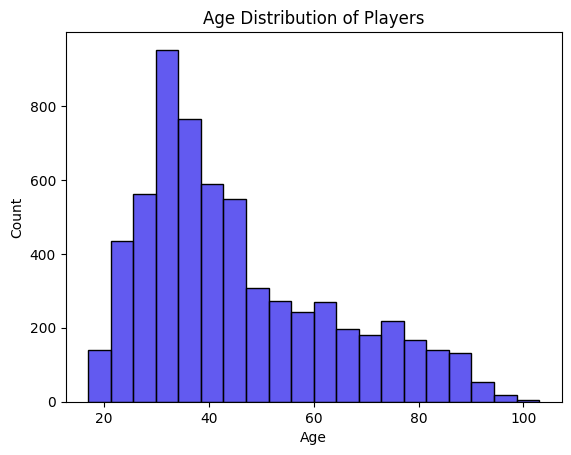

In [621]:
#   Age distribution
plt.figure()
sns.histplot(players['age'], bins=20, color='#2D23EB')
plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [622]:
#   Gender distribution
players['gender'].value_counts()

gender
M    6701
Name: count, dtype: int64

In [623]:
players[players['gender']=='F']

,player_id,player_object_id,player_name,dob,dod,gender,batting_style,bowling_style,country_id,image_url,image_metadata,end_date,age


In [624]:
#   Batting style
players['batting_style'].value_counts()

batting_style
right-hand bat    5416
left-hand bat     1192
Name: count, dtype: int64

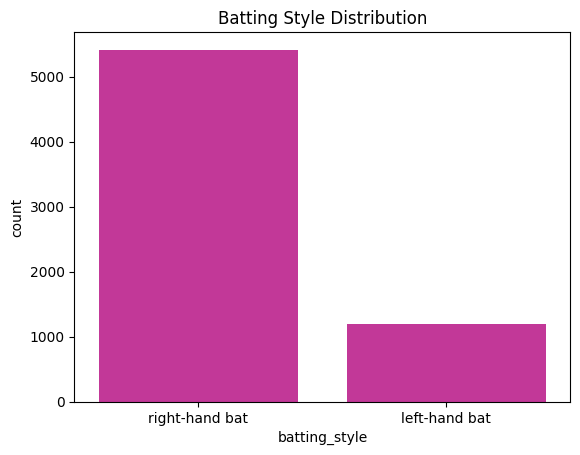

In [625]:
#   Batting style count
plt.figure()
sns.countplot(x=players['batting_style'], color='#D921A1')
plt.title("Batting Style Distribution")
plt.show()


In [626]:
#   Bowling style
players['bowling_style'].value_counts()


bowling_style
right-arm medium          1402
right-arm offbreak        1046
right-arm medium-fast      636
right-arm fast-medium      629
slow left-arm orthodox     519
legbreak                   356
right-arm fast             265
legbreak googly            195
left-arm medium            144
left-arm fast-medium       115
left-arm medium-fast        92
right-arm bowler            51
left-arm wrist-spin         30
right-arm slow              26
left-arm fast               22
right-arm slow-medium        6
left-arm bowler              5
left-arm slow                5
left-arm slow-medium         2
(unknown arm) slow           1
Name: count, dtype: int64

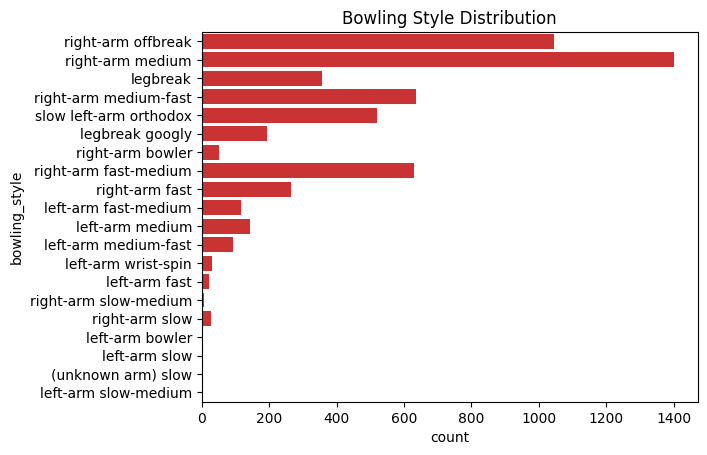

In [627]:
plt.figure()
sns.countplot(y=players['bowling_style'],color="#E21A1A")
plt.title("Bowling Style Distribution")
plt.show()

In [628]:
#   Country-wise Player Count
ctry = players['country_id'].value_counts().head(40)
ctry.head()

country_id
1.0    750
2.0    526
3.0    402
6.0    391
4.0    384
Name: count, dtype: int64

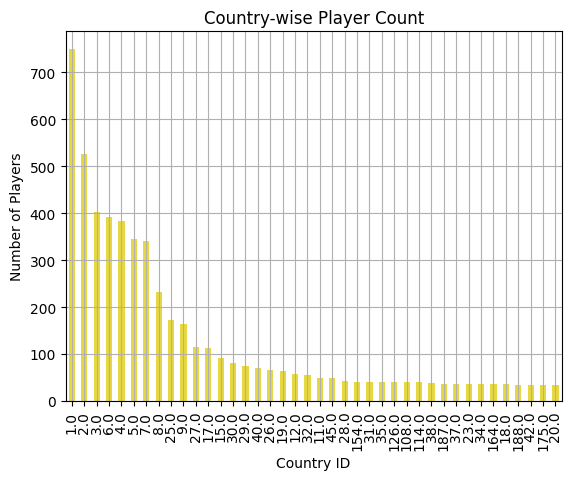

In [629]:
ctry.plot(kind='bar',x=players['country_id'],color= "#E2D11AD4", grid=True)
plt.title("Country-wise Player Count")
plt.ylabel('Number of Players')
plt.xlabel('Country ID')
plt.show()

In [630]:
batting.head()

,Match ID,innings,team,batsman,runs,balls,fours,sixes,strikeRate,isOut,wicketType,fielders,bowler
0,361657,1,Zimbabwe,10423.0,53.0,38.0,5.0,3.0,139.47,True,run out,['47099'],NaN
1,361657,1,Zimbabwe,49282.0,12.0,22.0,2.0,0.0,54.54,True,caught,['47738'],8270.0
2,361657,1,Zimbabwe,47619.0,8.0,26.0,0.0,0.0,30.76,True,caught,['19596'],47099.0
3,361657,1,Zimbabwe,10421.0,4.0,6.0,1.0,0.0,66.66,True,caught,['8270'],4169.0
4,361660,1,Pakistan,11647.0,44.0,41.0,4.0,1.0,107.31,True,caught,['15267'],50377.0


In [631]:
bowling.head()

,Match ID,innings,team,opposition,bowler id,overs,balls,maidens,conceded,wickets,economy,dots,fours,sixes,wides,noballs
0,300436,1,New Zealand,England,10303.0,4.0,24.0,0.0,35.0,1.0,8.75,10.0,3.0,2.0,1.0,0.0
1,300436,1,New Zealand,England,9711.0,4.0,24.0,0.0,45.0,1.0,11.25,5.0,6.0,1.0,1.0,0.0
2,300436,1,New Zealand,England,10325.0,3.0,18.0,0.0,43.0,2.0,14.33,5.0,3.0,4.0,1.0,0.0
3,300436,1,New Zealand,England,49108.0,4.0,24.0,0.0,22.0,2.0,5.50,10.0,1.0,1.0,0.0,0.0
4,300436,1,New Zealand,England,9570.0,3.0,18.0,0.0,25.0,0.0,8.33,8.0,3.0,1.0,0.0,0.0


In [632]:
matches.sample(2)

,T20I Match No,Match ID,Match Name,Series ID,Series Name,Match Date,Match Format,Team1 ID,Team1 Name,Team1 Captain,...,Umpire 2,Match Referee,Toss Winner,Toss Winner Choice,Match Winner,Match Result Text,MOM Player,Team1 Playing 11,Team2 Playing 11,Debut Players
2432,2430,1388217,New Zealand Vs Pakistan 2Nd T20I,1388185,Pakistan in New Zealand - 2024 (2023/24),2024-01-14,T20,5,New Zealand,51088,...,WR Knights,JJ Crowe,Pakistan,bowl,New Zealand,New Zealand won by 21 runs,89097.0,"['89097', '58403', '51088', '58772', '80639', ...","['103773', '54018', '56880', '65101', '63619',...",[]
1987,1987,1348323,Zimbabwe Vs Ireland 1St T20I,1348321,Ireland in Zimbabwe - 2023 (2022/23),2023-01-12,T20,29,Ireland,52628,...,L Rusere,AJ Pycroft,Zimbabwe,bowl,Zimbabwe,Zimbabwe won by 5 wickets (with 12 balls remai...,64447.0,"['52628', '62913', '89739', '89741', '69644', ...","['47205', '88165', '87157', '49115', '47206', ...","['49115', '62913', '89739']"


In [633]:
partnership.head()

,Match ID,innings,for wicket,team,opposition,player1,player2,player1 runs,player2 runs,player1 balls,player2 balls,partnership runs,partnership balls
0,361660,1,1.0,Pakistan,Sri Lanka,11647.0,47738.0,0.0,0.0,0.0,5.0,9.0,10.0
1,361660,1,2.0,Pakistan,Sri Lanka,4169.0,11647.0,14.0,9.0,13.0,8.0,25.0,21.0
2,361660,1,3.0,Pakistan,Sri Lanka,10439.0,11647.0,0.0,1.0,4.0,3.0,1.0,7.0
3,361660,1,4.0,Pakistan,Sri Lanka,8270.0,11647.0,19.0,22.0,19.0,16.0,46.0,35.0
4,361660,1,5.0,Pakistan,Sri Lanka,11647.0,19596.0,6.0,8.0,9.0,10.0,18.0,19.0


In [634]:
batting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56357 entries, 0 to 56356
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Match ID    56357 non-null  int64  
 1   innings     56357 non-null  int64  
 2   team        56331 non-null  object 
 3   batsman     56331 non-null  float64
 4   runs        41872 non-null  float64
 5   balls       41872 non-null  float64
 6   fours       41872 non-null  float64
 7   sixes       41872 non-null  float64
 8   strikeRate  41872 non-null  float64
 9   isOut       56331 non-null  object 
 10  wicketType  56331 non-null  object 
 11  fielders    32083 non-null  object 
 12  bowler      27757 non-null  float64
dtypes: float64(7), int64(2), object(4)
memory usage: 5.6+ MB


In [635]:
bowling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30648 entries, 0 to 30647
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Match ID    30648 non-null  int64  
 1   innings     30648 non-null  int64  
 2   team        30622 non-null  object 
 3   opposition  30622 non-null  object 
 4   bowler id   30622 non-null  float64
 5   overs       30622 non-null  float64
 6   balls       30622 non-null  float64
 7   maidens     30622 non-null  float64
 8   conceded    30622 non-null  float64
 9   wickets     30622 non-null  float64
 10  economy     30622 non-null  float64
 11  dots        28275 non-null  float64
 12  fours       28275 non-null  float64
 13  sixes       28275 non-null  float64
 14  wides       30622 non-null  float64
 15  noballs     30622 non-null  float64
dtypes: float64(12), int64(2), object(2)
memory usage: 3.7+ MB


In [636]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2592 entries, 0 to 2591
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   T20I Match No          2592 non-null   int64  
 1   Match ID               2592 non-null   int64  
 2   Match Name             2592 non-null   object 
 3   Series ID              2592 non-null   int64  
 4   Series Name            2592 non-null   object 
 5   Match Date             2581 non-null   object 
 6   Match Format           2592 non-null   object 
 7   Team1 ID               2592 non-null   int64  
 8   Team1 Name             2592 non-null   object 
 9   Team1 Captain          2592 non-null   int64  
 10  Team1 Runs Scored      2579 non-null   float64
 11  Team1 Wickets Fell     2579 non-null   float64
 12  Team1 Extras Rec       2579 non-null   float64
 13  Team2 ID               2592 non-null   int64  
 14  Team2 Name             2592 non-null   object 
 15  Team

In [637]:
partnership.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36799 entries, 0 to 36798
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Match ID           36799 non-null  int64  
 1   innings            36799 non-null  int64  
 2   for wicket         36773 non-null  float64
 3   team               36773 non-null  object 
 4   opposition         36773 non-null  object 
 5   player1            36773 non-null  float64
 6   player2            36773 non-null  float64
 7   player1 runs       36773 non-null  float64
 8   player2 runs       36773 non-null  float64
 9   player1 balls      36773 non-null  float64
 10  player2 balls      36773 non-null  float64
 11  partnership runs   36773 non-null  float64
 12  partnership balls  36773 non-null  float64
dtypes: float64(9), int64(2), object(2)
memory usage: 3.6+ MB


In [638]:
batting.size

732641

In [639]:
bowling.size

490368

In [640]:
matches.size

85536

In [641]:
partnership.size

478387

__Data Cleaning__

In [642]:
players.replace('-',0,inplace=True)
batting.replace('-',0,inplace=True)
bowling.replace('-',0,inplace=True)
partnership.replace('-',0,inplace=True)

players.fillna(0,inplace=True)
batting.fillna(0,inplace=True)
bowling.fillna(0,inplace=True)
bowling.fillna(0,inplace=True)

C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\2449049965.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  players.fillna(0,inplace=True)


__Top Run Scorers__

In [643]:
batting['runs'] = batting['runs'].astype(int)
top_batsmen = batting.groupby('batsman')['runs'].sum().sort_values(ascending=False).head(10)
print(top_batsmen)


batsman
49752.0    4037
48405.0    3974
56880.0    3823
48927.0    3531
52631.0    3491
35812.0    3120
48739.0    3099
54018.0    3048
53271.0    2927
51088.0    2547
Name: runs, dtype: int64


In [644]:
# Merging tabels (batsman and players) 
batting_merged = batting.merge(
    players,
    left_on='batsman',
    right_on='player_id',
    how='left'
)
batting_merged.head(1)


,Match ID,innings,team,batsman,runs,balls,fours,sixes,strikeRate,isOut,...,dob,dod,gender,batting_style,bowling_style,country_id,image_url,image_metadata,end_date,age
0,361657,1,Zimbabwe,10423.0,53,38.0,5.0,3.0,139.47,True,...,1983-08-09 00:00:00,0,M,right-hand bat,right-arm medium,9.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 203311, 'url': '/db/PICTURES/CMS/203300...",2026-02-07 10:27:46.455042,42.0


In [646]:
batting_merged['runs'] = (
    pd.to_numeric(batting['runs'], errors='coerce')
    .fillna(0)
    .astype(int)
)

top_batsmen = batting_merged.groupby('player_name')['runs'].sum().sort_values(ascending=False).head(10)


print(top_batsmen)


player_name
Virat Kohli        4037
Rohit Sharma       3974
Babar Azam         3823
Martin Guptill     3531
Paul Stirling      3491
Aaron Finch        3120
David Warner       3099
Mohammad Rizwan    3048
Jos Buttler        2927
Kane Williamson    2547
Name: runs, dtype: int64


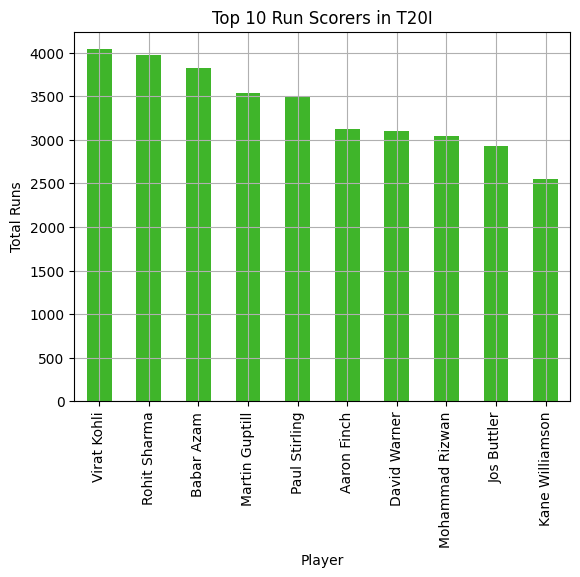

In [647]:
top_batsmen.plot(kind='bar', color='#3FB52A', grid=True)
plt.title("Top 10 Run Scorers in T20I")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.show()


__Top 10 AVG run by the batsman__

In [648]:
consistency = (
    batting_merged
    .groupby(['player_name'])['runs']
    .mean()
    .reset_index(name='AVG Score')
    .sort_values('AVG Score', ascending=False)
    .head(15) 
)

consistency

,player_name,AVG Score
2017,Michael Levitt,61.750000
1163,Gustav Mckeon,57.181818
1920,Marcus Trescothick,55.333333
1738,Kranthi Venkataswamy,55.000000
987,Faheem Nazir,51.714286
1860,Ma'ara Ave,48.333333
2015,Michael Klinger,47.666667
1095,George Worker,45.000000
16,Aaron Johnson,44.562500
547,Bilal Masud,44.500000


<Axes: xlabel='player_name'>

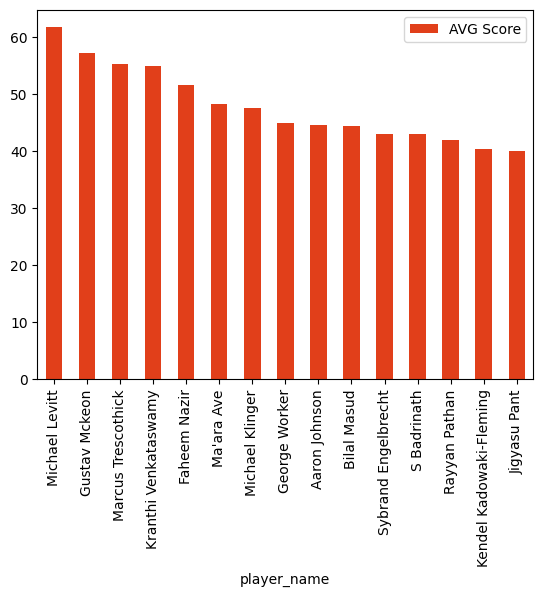

In [649]:
consistency.plot(x='player_name',kind='bar',color="#E13F1A")

__Players with Top Strike Rate__

In [650]:
batting['strikeRate'] = batting['strikeRate'].astype(float)

consistency = batting.groupby('batsman')['strikeRate'].std().reset_index(name='Top_Strike_Rate').sort_values('Top_Strike_Rate',ascending=False)
print(consistency.head(10))


       batsman  Top_Strike_Rate
3081  109878.0       346.410162
3028  109668.0       339.423531
2597  105139.0       334.320661
2607  105150.0       270.048944
2543  104516.0       230.940108
1944   92089.0       200.923608
3091  109955.0       194.375100
895    54432.0       193.269317
1759   78275.0       192.448165
2385  103317.0       188.564165


In [651]:
batting_merged['strikeRate'] = (
    pd.to_numeric(batting['strikeRate'])
    .fillna(0)
    .astype(int)
)

top_SR_batsmen = (
    batting_merged[batting_merged['balls']>30]
    .groupby(['player_name'])['strikeRate'].mean()
    .reset_index(name='AVG SR')
    .sort_values('AVG SR',ascending=False)
    .head(20)
)

print(top_SR_batsmen)


                 player_name  AVG SR
452   Jan Nicol Loftie-Eaton  280.00
165              Bilal Masud  248.00
566         Liam Livingstone  239.00
709           Nathan Knights  222.00
744              Ollie Hairs  220.50
918           Shaheryar Butt  215.00
641              Mirza Ahsan  212.00
549             Kushal Malla  209.25
136               Axar Patel  209.00
377              Harry Brook  208.50
1124        Zeeshan Kukikhel  203.00
526            Kevin D'Souza  200.00
313          Frank Akankwasa  200.00
601               Mark Adair  200.00
763       Patrick Matautaava  198.00
805              Ramon Sealy  198.00
299             Faisal Javed  196.00
359      Hadisullah Tarakhel  195.00
791          Rachin Ravindra  194.00
173         Brandon McMullen  193.00


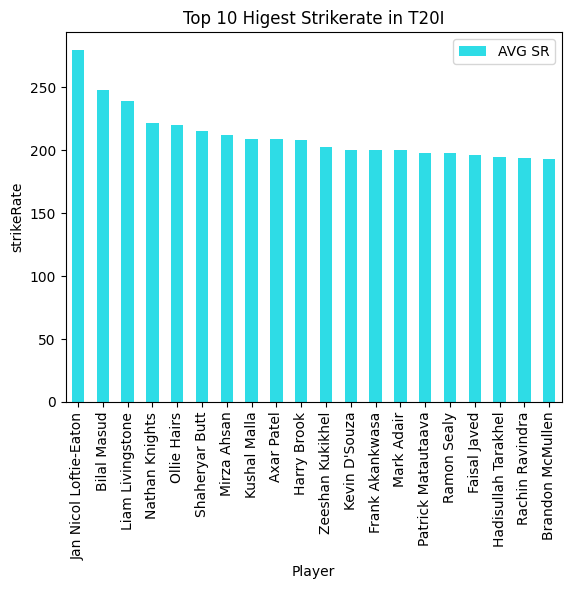

In [652]:
top_SR_batsmen.plot(kind='bar', x='player_name',color='#2EDCE6')
plt.title("Top 10 Higest Strikerate in T20I")
plt.xlabel("Player")
plt.ylabel("strikeRate")
plt.show()

__Players with AVG_Run > 20 and Top AVG_SR__

In [655]:
sr_avg = batting_merged.groupby(['player_name','team']).agg(
    Avg_Runs=('runs', 'mean'),
    Avg_SR=('strikeRate', 'mean')
)

# Filter meaningful players
sr_avg = sr_avg[sr_avg['Avg_Runs'] > 20]
print(sr_avg.sort_values('Avg_SR', ascending=False).head(10))

                                 Avg_Runs      Avg_SR
player_name       team                               
Thisara Perera    World-XI      32.000000  216.016667
Zaid Soulat       Bulgaria      20.666667  206.410000
Christiaan Jonker South Africa  28.500000  182.080000
Ben Fitchet       Guernsey      31.500000  179.165000
Shahid Afridi     Germany       20.857143  176.702857
Sheikh Rasik      Hungary       39.000000  174.765000
Akshay Harikumar  Bulgaria      22.000000  169.230000
Donovan Ferreira  South Africa  30.000000  168.830000
Nitish Kumar      U.S.A.        64.000000  168.420000
Arsalan Arif      Austria       26.500000  166.390000


In [662]:
import pandas as pd

In [660]:
players = pd.read_csv("T20i Data set\players_info.csv")
batting = pd.read_csv("T20i Data set\T20i_Batting_Card.csv")
bowling = pd.read_csv("T20i Data set\T20i_Bowling_Card.csv")
matches = pd.read_csv("T20i Data set\T20i_Matches_Data.csv")
partnership = pd.read_csv("T20i Data set\T20i_Partnership_Card.csv")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\914035868.py:1: SyntaxWarning: invalid escape sequence '\p'
  players = pd.read_csv("T20i Data set\players_info.csv")
C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\914035868.py:2: SyntaxWarning: invalid escape sequence '\T'
  batting = pd.read_csv("T20i Data set\T20i_Batting_Card.csv")
C:\Users\shreyas\AppData\Local\Temp\ipykernel_19532\914035868.py:3: SyntaxWarning: invalid escape sequence '\T'
  bowling = pd.read_csv("T20i Data set\T20i

In [656]:
# Merging tabels (batsman and players) 
batting_merged = batting.merge(
    players,
    left_on='batsman',
    right_on='player_id',
    how='left'
)

_Joint Plot for Run/strikeRate_

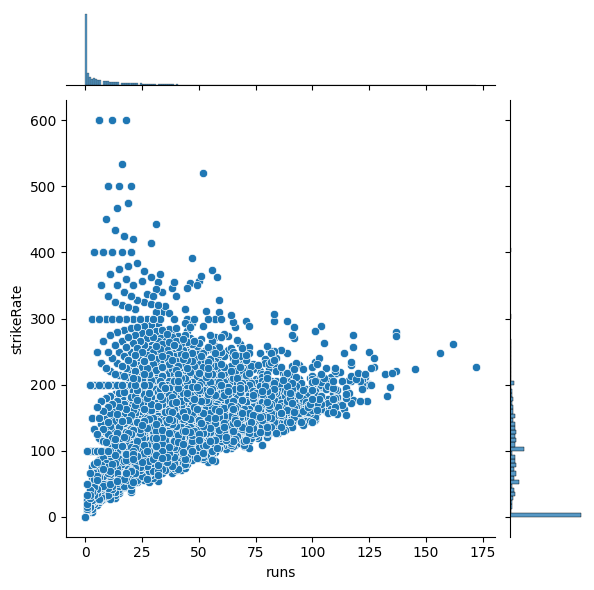

In [657]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.jointplot(data = batting_merged, x='runs', y='strikeRate')
plt.show()

In [658]:
batting_merged.head(1)

,Match ID,innings,team,batsman,runs,balls,fours,sixes,strikeRate,isOut,...,dob,dod,gender,batting_style,bowling_style,country_id,image_url,image_metadata,end_date,age
0,361657,1,Zimbabwe,10423.0,53,38.0,5.0,3.0,139.47,True,...,1983-08-09 00:00:00,0,M,right-hand bat,right-arm medium,9.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 203311, 'url': '/db/PICTURES/CMS/203300...",2026-02-07 10:27:46.455042,42.0


__Top Wicket Takers__

In [659]:
bowling['wickets'] = bowling['wickets'].astype(int)

top_bowlers = bowling.groupby('bowler id')['wickets'].sum().sort_values(ascending=False).head(10)
print(top_bowlers)


bowler id
49108.0    157
48277.0    140
79159.0    138
67586.0    136
64864.0    111
49427.0    107
66012.0    107
84937.0    107
54674.0    107
45105.0    107
Name: wickets, dtype: int64


In [541]:
# Merging tabels (bowler and players) 
bowler_merged = bowling.merge(
    players,
    left_on='bowler id',
    right_on='player_id',
    how='left'
)

In [542]:
bowler_merged['wickets'] = (
    pd.to_numeric(bowler_merged['wickets'])
    .fillna(0)
    .astype(int)
)

top_bowlers = (
    bowler_merged.groupby('player_name')['wickets'].sum()
    .reset_index(name='Total Wickets')
    .sort_values('Total Wickets',ascending=False)
    
)

print(top_bowlers.head(10))

            player_name  Total Wickets
2311        Tim Southee            157
2076    Shakib Al Hasan            140
1821        Rashid Khan            139
927           Ish Sodhi            136
1422   Mitchell Santner            111
1229     Lasith Malinga            107
1328         Mark Adair            107
1555  Mustafizur Rahman            107
65          Adil Rashid            107
2052        Shadab Khan            107


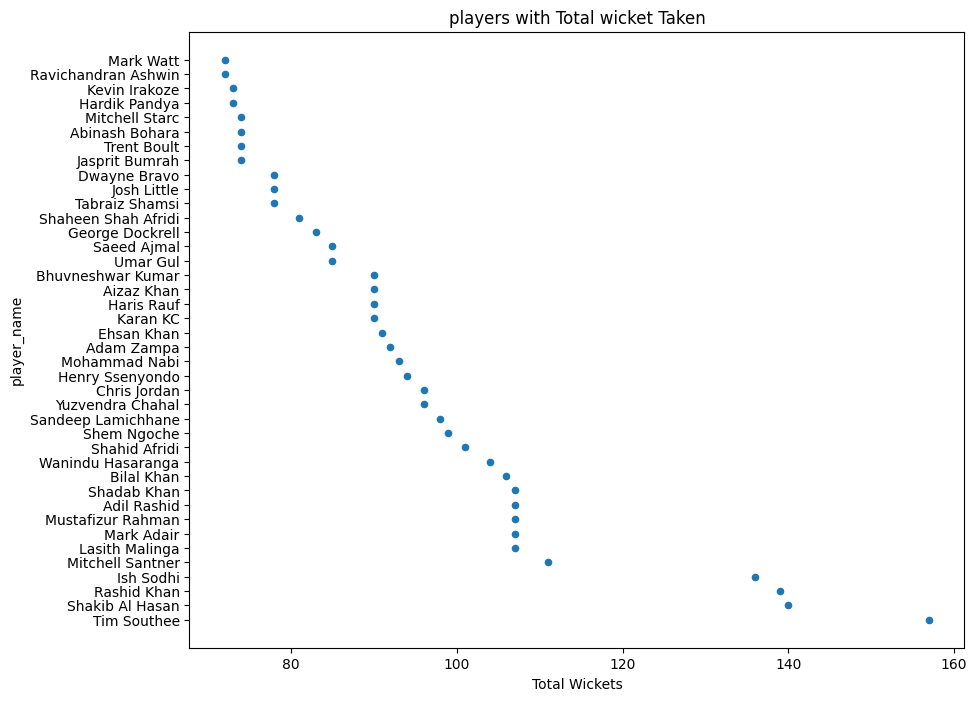

In [543]:
top_bowlers.head(40).plot(kind='scatter',y='player_name', x='Total Wickets',figsize=(10,8))
plt.title('players with Total wicket Taken')
plt.show()

__Economy Rate Analysis__

In [544]:
bowling['economy'] = bowling['economy'].astype(float)

best_economy = bowling[bowling['balls']>12].groupby('bowler id')['economy'].mean().sort_values()

print(best_economy.head(10))

bowler id
116116.0    0.75
106304.0    1.33
88991.0     1.50
62003.0     1.50
115121.0    1.71
115942.0    1.75
46557.0     2.00
98578.0     2.00
81437.0     2.33
78229.0     2.33
Name: economy, dtype: float64


In [545]:
bowler_merged['economy'] = (
    pd.to_numeric(bowler_merged['economy'])
    .fillna(0)
    .astype(float)
)

ec_bowlers = (
    bowler_merged[bowler_merged['balls']>12].groupby('player_name')['economy'].mean()
    .sort_values(ascending=True)
    .head(10)
)

print(ec_bowlers)

player_name
Lucas Rossi            0.75
Rajendra Pisal         1.33
Bhuvan Karki           1.50
Aaron Jones            1.50
Vinoth Ravindran       1.71
Tholal Mohamed Raya    1.75
Richard Agamiire       2.00
Steven Welsh           2.00
Charith Asalanka       2.33
Zain Abbasi            2.33
Name: economy, dtype: float64


<Axes: xlabel='economy', ylabel='player_name'>

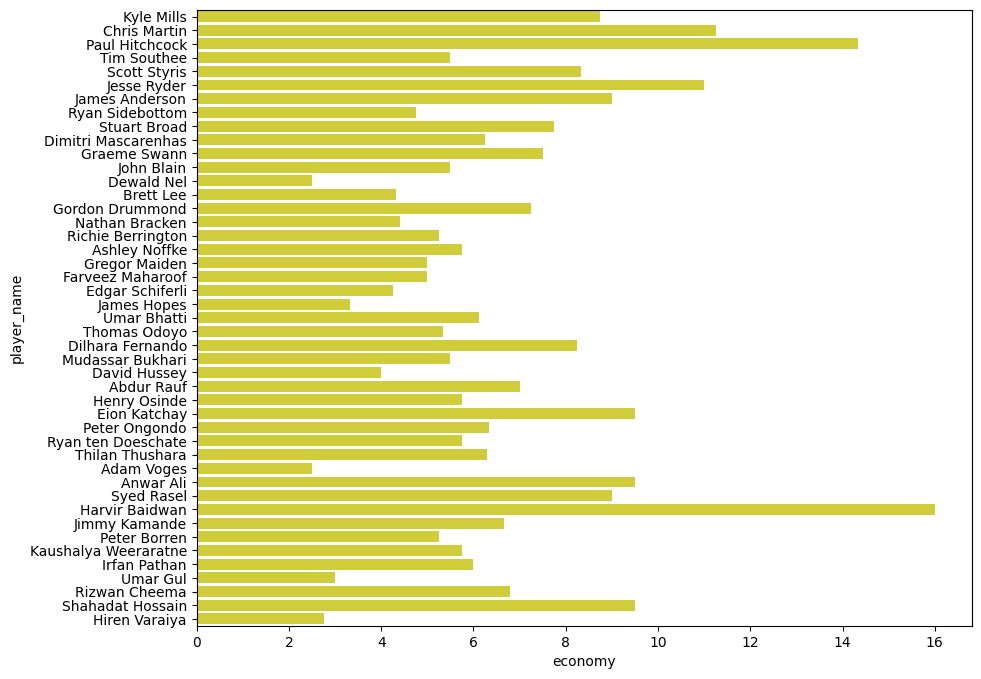

In [546]:
plt.figure(figsize=(10,8))
sns.barplot(data=bowler_merged.head(50), y='player_name', x='economy', errorbar=None, color="#EBE41F")

__All-Rounder Impact Score__

In [547]:
bat_runs = batting_merged.groupby('player_name')['runs'].sum()
bowl_wkts = bowler_merged.groupby('player_name')['wickets'].sum()

all_rounders = pd.concat([bat_runs, bowl_wkts], axis=1)
all_rounders.columns = ['runs', 'wickets']
all_rounders.fillna(0, inplace=True)

all_rounders = all_rounders[(all_rounders['runs']>200) & (all_rounders['wickets']>20)]

all_rounders['Impact_Score'] = all_rounders['runs'] + (all_rounders['wickets'] * 30)
print(all_rounders.sort_values('Impact_Score', ascending=False).head(20))


                   runs  wickets  Impact_Score
player_name                                   
Shakib Al Hasan    2382    140.0        6582.0
Tim Southee         303    157.0        5013.0
Mohammad Nabi      2109     93.0        4899.0
Shahid Afridi      1562    101.0        4592.0
Rashid Khan         406    139.0        4576.0
Mohammad Hafeez    2514     61.0        4344.0
Virandeep Singh    2320     66.0        4300.0
Mitchell Santner    650    111.0        3980.0
Shadab Khan         632    107.0        3842.0
Mark Adair          583    107.0        3793.0
Wanindu Hasaranga   650    104.0        3770.0
Kevin O'Brien      1973     58.0        3713.0
Glenn Maxwell      2468     40.0        3668.0
Sikandar Raza      1858     59.0        3628.0
Dwayne Bravo       1255     78.0        3595.0
Aizaz Khan          877     90.0        3577.0
Hardik Pandya      1348     73.0        3538.0
George Dockrell     977     83.0        3467.0
Shem Ngoche         447     99.0        3417.0
Mahmudullah  

<Axes: xlabel='Impact_Score', ylabel='player_name'>

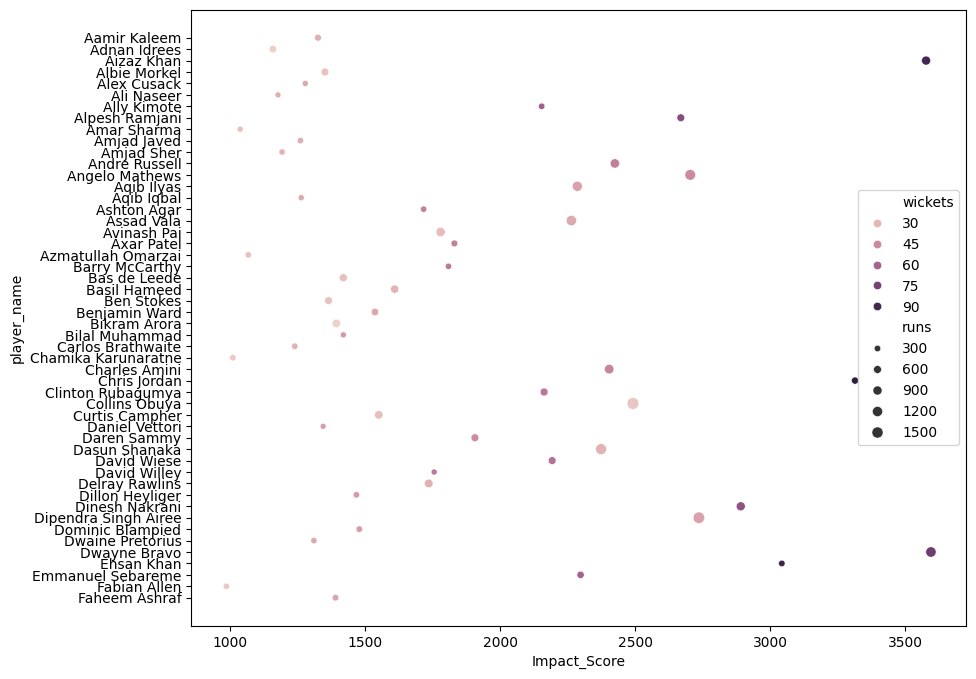

In [548]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=all_rounders.head(50), y='player_name', x='Impact_Score', size='runs', hue='wickets',)

__Partnership Effectiveness__

In [549]:
partnership['partnership runs'] = partnership['partnership runs'].fillna(0).astype(int)

best_pairs = partnership.groupby(['player1', 'player2'])['partnership runs'].sum().sort_values(ascending=False).head(10)
print(best_pairs)


player1  player2 
54018.0  56880.0     2949
52628.0  52631.0     1998
48405.0  60530.0     1897
15887.0  48405.0     1742
47397.0  52631.0     1720
35812.0  48739.0     1582
46048.0  72409.0     1573
48927.0  51088.0     1389
52091.0  110547.0    1376
46888.0  65861.0     1228
Name: partnership runs, dtype: int64


In [550]:
partnership_merged = partnership

In [551]:
# Merging tabels (partnership and players) 

partnership_merged = partnership.merge(
    players[['player_id', 'player_name']],
    left_on='player1',
    right_on='player_id',
    how='left'
)
partnership_merged = partnership_merged.rename(columns={'player_id': 'player1_id', 'player_name':'player1_name'})




In [552]:
partnership_merged = partnership_merged.merge(
    players[['player_id', 'player_name']],
    left_on='player2',
    right_on='player_id',
    how='left'
)
partnership_merged = partnership_merged.rename(columns={'player_id': 'player2_id', 'player_name':'player2_name'})


In [553]:
partnership_merged.head(2)

,Match ID,innings,for wicket,team,opposition,player1,player2,player1 runs,player2 runs,player1 balls,player2 balls,partnership runs,partnership balls,player1_id,player1_name,player2_id,player2_name
0,361660,1,1.0,Pakistan,Sri Lanka,11647.0,47738.0,0.0,0.0,0.0,5.0,9,10.0,11647.0,Salman Butt,47738.0,Shoaib Khan
1,361660,1,2.0,Pakistan,Sri Lanka,4169.0,11647.0,14.0,9.0,13.0,8.0,25,21.0,4169.0,Shahid Afridi,11647.0,Salman Butt


In [554]:
partnership_merged[['player1', 'player1_name', 'player2', 'player2_name']].head()

,player1,player1_name,player2,player2_name
0,11647.0,Salman Butt,47738.0,Shoaib Khan
1,4169.0,Shahid Afridi,11647.0,Salman Butt
2,10439.0,Younis Khan,11647.0,Salman Butt
3,8270.0,Shoaib Malik,11647.0,Salman Butt
4,11647.0,Salman Butt,19596.0,Misbah-ul-Haq


In [555]:
partnership_merged['partnership runs'] = partnership_merged['partnership runs'].fillna(0).astype(int)

best_pairs = partnership_merged.groupby(['player1_name', 'player2_name'])['partnership runs'].sum().reset_index(name='Total Runs').sort_values('Total Runs',ascending=False)
print(best_pairs.head(10))

          player1_name       player2_name  Total Runs
8384   Mohammad Rizwan         Babar Azam        2949
1155    Andy Balbirnie      Paul Stirling        1998
10488     Rohit Sharma           KL Rahul        1897
11662   Shikhar Dhawan       Rohit Sharma        1742
6580     Kevin O'Brien      Paul Stirling        1720
57         Aaron Finch       David Warner        1582
6855      Kyle Coetzer      George Munsey        1573
7695    Martin Guptill    Kane Williamson        1389
258        Abhik Patwa      Ivan Selemani        1376
8320     Mohammad Nabi  Najibullah Zadran        1228


__Match Winning Analysis__

In [556]:
match_wins = matches['Match Winner'].value_counts()
match_wins.head(10)


Match Winner
India           140
Pakistan        138
New Zealand     109
Australia       100
South Africa     96
England          94
Sri Lanka        85
West Indies      80
Afghanistan      79
Uganda           69
Name: count, dtype: int64

<Axes: xlabel='Match Winner'>

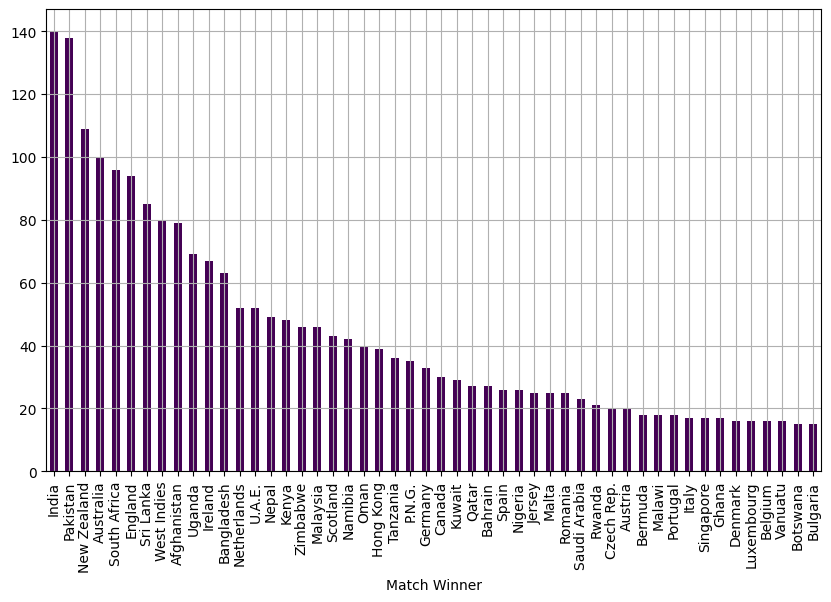

In [557]:
match_wins.head(50).plot(kind='bar', colormap='viridis', figsize=(10,6), grid=True)

__Team Strength Score__

In [558]:
team_runs = batting.groupby('team')['runs'].sum()
team_wkts = bowling.groupby('team')['wickets'].sum()

team_strength = pd.concat([team_runs, team_wkts], axis=1)
team_strength.columns = ['Total_Runs', 'Total_Wickets']
team_strength.fillna(0, inplace=True)

team_strength['Strength_Score'] = team_strength['Total_Runs'] + (team_strength['Total_Wickets'] * 25)
team_strength.sort_values('Strength_Score', ascending=False).head(10)


,Total_Runs,Total_Wickets,Strength_Score
team,,,
Pakistan,32922,1401,67947
India,32722,1309,65447
New Zealand,30903,1279,62878
Australia,27616,1149,56341
England,27240,1046,53390
West Indies,26051,1058,52501
South Africa,25100,1084,52200
Sri Lanka,25590,1054,51940
Bangladesh,21514,894,43864


<Axes: xlabel='team'>

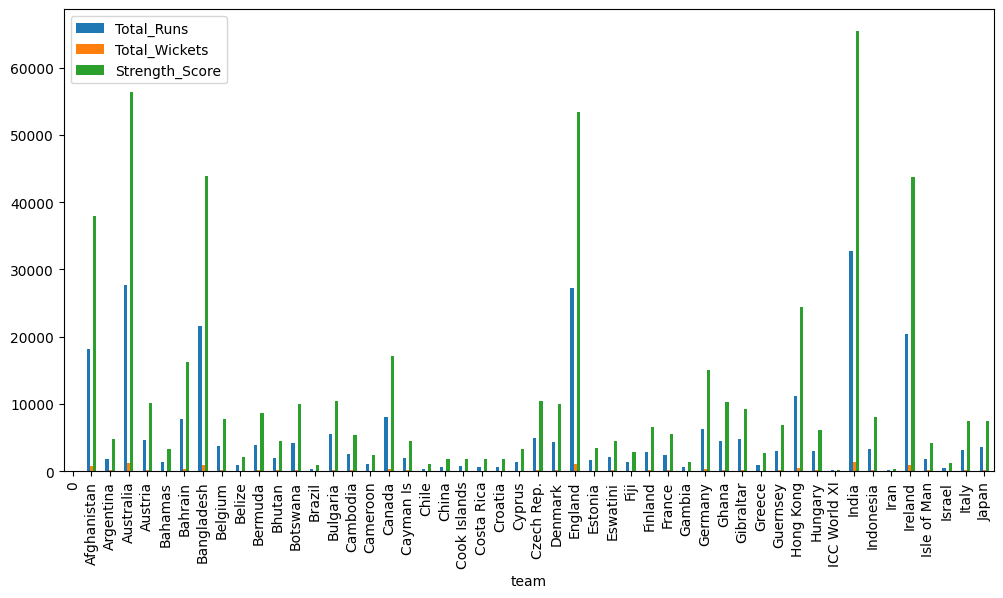

In [559]:
team_strength.head(50).plot(kind='bar', figsize=(12,6))

In [560]:
team_strength

,Total_Runs,Total_Wickets,Strength_Score
team,,,
0,0,0,0
Afghanistan,18218,790,37968
Argentina,1827,120,4827
Australia,27616,1149,56341
Austria,4565,225,10190
...,...,...,...
Uganda,10864,629,26589
Vanuatu,4083,212,9383
West Indies,26051,1058,52501


In [561]:
partnership.columns

Index(['Match ID', 'innings', 'for wicket', 'team', 'opposition', 'player1',
       'player2', 'player1 runs', 'player2 runs', 'player1 balls',
       'player2 balls', 'partnership runs', 'partnership balls'],
      dtype='object')

In [562]:
bowling.columns

Index(['Match ID', 'innings', 'team', 'opposition', 'bowler id', 'overs',
       'balls', 'maidens', 'conceded', 'wickets', 'economy', 'dots', 'fours',
       'sixes', 'wides', 'noballs'],
      dtype='object')

In [563]:
batting.columns

Index(['Match ID', 'innings', 'team', 'batsman', 'runs', 'balls', 'fours',
       'sixes', 'strikeRate', 'isOut', 'wicketType', 'fielders', 'bowler'],
      dtype='object')

In [564]:
players.columns

Index(['player_id', 'player_object_id', 'player_name', 'dob', 'dod', 'gender',
       'batting_style', 'bowling_style', 'country_id', 'image_url',
       'image_metadata', 'end_date', 'age'],
      dtype='object')

In [565]:
matches.groupby(['Match Venue (Country)'])['Match Venue (Country)'].value_counts().reset_index(name='No. Matchs').sort_values('No. Matchs',ascending=False).head(25)

,Match Venue (Country),No. Matchs
61,United Arab Emirates,245
55,South Africa,146
50,Rwanda,140
26,India,131
43,Oman,131
64,West Indies,125
3,Bangladesh,110
1,Australia,104
41,New Zealand,96
15,England,91


In [566]:
matches.groupby(['Match Venue (Country)','Match Venue (City)'])['Match Venue (City)'].value_counts().reset_index(name='No. Matchs').head(20)

,Match Venue (Country),Match Venue (City),No. Matchs
0,Argentina,Buenos Aires,15
1,Australia,Adelaide,13
2,Australia,Brisbane,10
3,Australia,Canberra,5
4,Australia,Carrara,2
5,Australia,Geelong,7
6,Australia,Hobart,13
7,Australia,Melbourne,19
8,Australia,Perth,10
9,Australia,Sydney,22


In [567]:
matches.groupby(['Match Venue (Country)','Match Venue (City)'])['Match Venue (Stadium)'].value_counts().reset_index(name='No. Matchs').head(20)

,Match Venue (Country),Match Venue (City),Match Venue (Stadium),No. Matchs
0,Argentina,Buenos Aires,Belgrano Athletic Club Ground,4
1,Argentina,Buenos Aires,Hurlingham Club Ground,4
2,Argentina,Buenos Aires,St Albans Club,4
3,Argentina,Buenos Aires,St George's College Ground,3
4,Australia,Adelaide,Adelaide Oval,13
5,Australia,Brisbane,Brisbane Cricket Ground,10
6,Australia,Canberra,Manuka Oval,5
7,Australia,Carrara,Carrara Oval,2
8,Australia,Geelong,GMHBA Stadium,6
9,Australia,Geelong,Simonds Stadium,1


In [568]:
matches.columns

Index(['T20I Match No', 'Match ID', 'Match Name', 'Series ID', 'Series Name',
       'Match Date', 'Match Format', 'Team1 ID', 'Team1 Name', 'Team1 Captain',
       'Team1 Runs Scored', 'Team1 Wickets Fell', 'Team1 Extras Rec',
       'Team2 ID', 'Team2 Name', 'Team2 Captain', 'Team2 Runs Scored',
       'Team2 Wickets Fell', 'Team2 Extras Rec', 'Match Venue (Stadium)',
       'Match Venue (City)', 'Match Venue (Country)', 'Umpire 1', 'Umpire 2',
       'Match Referee', 'Toss Winner', 'Toss Winner Choice', 'Match Winner',
       'Match Result Text', 'MOM Player', 'Team1 Playing 11',
       'Team2 Playing 11', 'Debut Players'],
      dtype='object')

In [569]:
players.columns

Index(['player_id', 'player_object_id', 'player_name', 'dob', 'dod', 'gender',
       'batting_style', 'bowling_style', 'country_id', 'image_url',
       'image_metadata', 'end_date', 'age'],
      dtype='object')

In [570]:
matches_merged = matches.merge(
    players[['player_id','player_name']],
    left_on= 'Team1 Captain',
    right_on= 'player_id',
    how='left'
)
matches_merged = matches_merged.rename(columns={'player_name' : 'Team1 Captain Name', 'player_id': 'Team1 Captain ID'})

In [571]:
matches_merged.columns

Index(['T20I Match No', 'Match ID', 'Match Name', 'Series ID', 'Series Name',
       'Match Date', 'Match Format', 'Team1 ID', 'Team1 Name', 'Team1 Captain',
       'Team1 Runs Scored', 'Team1 Wickets Fell', 'Team1 Extras Rec',
       'Team2 ID', 'Team2 Name', 'Team2 Captain', 'Team2 Runs Scored',
       'Team2 Wickets Fell', 'Team2 Extras Rec', 'Match Venue (Stadium)',
       'Match Venue (City)', 'Match Venue (Country)', 'Umpire 1', 'Umpire 2',
       'Match Referee', 'Toss Winner', 'Toss Winner Choice', 'Match Winner',
       'Match Result Text', 'MOM Player', 'Team1 Playing 11',
       'Team2 Playing 11', 'Debut Players', 'Team1 Captain ID',
       'Team1 Captain Name'],
      dtype='object')

In [572]:
matches_merged = matches_merged.merge(
    players[['player_id','player_name']],
    left_on= 'Team2 Captain',
    right_on= 'player_id',
    how='left'
)
matches_merged = matches_merged.rename(columns={'player_name' : 'Team2 Captain Name', 'player_id': 'Team2 Captain ID'})

In [573]:
matches_merged.groupby(['Team1 Name', 'Team1 Captain Name', 'Team2 Name', 'Team2 Captain Name'])['Match Winner'].value_counts().reset_index(name='No. Matches Win').sort_values('No. Matches Win', ascending=False).head(30)

,Team1 Name,Team1 Captain Name,Team2 Name,Team2 Captain Name,Match Winner,No. Matches Win
1736,Tanzania,Abhik Patwa,Rwanda,Clinton Rubagumya,Tanzania,7
1639,Sri Lanka,Dasun Shanaka,Australia,Aaron Finch,Australia,6
1823,Uganda,Brian Masaba,Rwanda,Clinton Rubagumya,Uganda,6
808,Jersey,Charles Perchard,Guernsey,Josh Butler,Jersey,5
180,Bangladesh,Mahmudullah,Pakistan,Babar Azam,Pakistan,5
1428,Rwanda,Clinton Rubagumya,Uganda,Brian Masaba,Uganda,5
1738,Tanzania,Abhik Patwa,Uganda,Brian Masaba,Uganda,5
295,Bulgaria,Prakash Mishra,Romania,Ramesh Satheesan,Romania,4
559,Gibraltar,Avinash Pai,Portugal,Najjam Shahzad,Portugal,4
352,Cayman Is,Ramon Sealy,Bahamas,Marc Taylor,Cayman Is,4


In [574]:
matches.groupby(['Team1 Name','Team2 Name'])['Toss Winner'].value_counts().reset_index(name='No. Toss Wins').head(30)

,Team1 Name,Team2 Name,Toss Winner,No. Toss Wins
0,Afghanistan,Bangladesh,Bangladesh,5
1,Afghanistan,Bangladesh,Afghanistan,2
2,Afghanistan,Canada,Afghanistan,1
3,Afghanistan,England,England,1
4,Afghanistan,Hong Kong,Afghanistan,2
5,Afghanistan,Hong Kong,Hong Kong,1
6,Afghanistan,India,India,4
7,Afghanistan,Ireland,Afghanistan,10
8,Afghanistan,Ireland,Ireland,7
9,Afghanistan,Kenya,Afghanistan,2


__Indian Team Performance analysis__

_Run by Indian Batsmans_

In [575]:

top_batsmen = (batting_merged[batting_merged['country_id']==6].groupby(['player_name'])['runs']
               .sum()
               .sort_values(ascending=False).head(10)

)
print(top_batsmen)
print()



player_name
Virat Kohli         4037
Rohit Sharma        3974
KL Rahul            2265
Suryakumar Yadav    2141
Shikhar Dhawan      1759
MS Dhoni            1617
Suresh Raina        1605
Hardik Pandya       1348
Yuvraj Singh        1177
Shreyas Iyer        1104
Name: runs, dtype: int64



_Higest Avg Run by Indian Batsman_

In [576]:
consistency = (
    batting_merged[batting_merged['country_id']==6]
    .groupby(['player_name'])['runs']
    .mean()
    .reset_index(name='AVG Score')
    .sort_values('AVG Score', ascending=False)
    .head(15) 
)
consistency

,player_name,AVG Score
75,S Badrinath,43.000000
18,Dinesh Mongia,38.000000
94,Suryakumar Yadav,35.683333
104,Virat Kohli,35.104348
30,KL Rahul,32.357143
107,Yashasvi Jaiswal,31.375000
63,Rahul Dravid,31.000000
38,Mandeep Singh,29.000000
74,Ruturaj Gaikwad,27.777778
83,Shikhar Dhawan,26.651515


_Avg SR by Indian Batsman_

In [577]:
top_SR_batsmen = (
    batting_merged[batting_merged['country_id']==6 ]
    .groupby(['player_name'])['strikeRate'].mean()
    .reset_index(name='AVG SR')
    .sort_values('AVG SR',ascending=False)
    .head(20)
)

print(top_SR_batsmen)


          player_name      AVG SR
94   Suryakumar Yadav  148.250000
63       Rahul Dravid  147.000000
105   Virender Sehwag  137.722222
69        Rinku Singh  137.642857
107  Yashasvi Jaiswal  129.250000
97        Tilak Varma  124.400000
101    Venkatesh Iyer  124.222222
65     Rahul Tripathi  118.000000
104       Virat Kohli  116.017391
75        S Badrinath  116.000000
87       Shubman Gill  115.857143
17     Dinesh Karthik  115.620690
37           MS Dhoni  115.587629
30           KL Rahul  114.600000
19     Gautam Gambhir  110.555556
73       Rohit Sharma  110.000000
83     Shikhar Dhawan  106.757576
52      Parthiv Patel  106.500000
21      Hardik Pandya  106.054348
86       Shreyas Iyer  106.040000


_Players with AVG_Run > 20 and Top AVG_SR in India_

In [578]:
sr_avg = batting_merged[batting_merged['country_id']==6 ].groupby(['player_name','team']).agg(
    Avg_Runs=('runs', 'mean'),
    Avg_SR=('strikeRate', 'mean')
)

# Filter players
sr_avg = sr_avg[sr_avg['Avg_Runs'] > 20]
print(sr_avg.sort_values('Avg_SR', ascending=False).head(20))

                         Avg_Runs      Avg_SR
player_name      team                        
Suryakumar Yadav India  35.683333  148.250000
Rahul Dravid     India  31.000000  147.000000
Virender Sehwag  India  21.888889  137.722222
Rinku Singh      India  25.428571  137.642857
Yashasvi Jaiswal India  31.375000  129.250000
Tilak Varma      India  22.400000  124.400000
Virat Kohli      India  35.104348  116.017391
S Badrinath      India  43.000000  116.000000
Shubman Gill     India  23.928571  115.857143
KL Rahul         India  32.357143  114.600000
Gautam Gambhir   India  25.888889  110.555556
Rohit Sharma     India  26.493333  110.000000
Shikhar Dhawan   India  26.651515  106.757576
Shreyas Iyer     India  22.080000  106.040000
Ishan Kishan     India  24.875000  105.093750
Yuvraj Singh     India  20.649123  104.912281
Mandeep Singh    India  29.000000  103.333333
Ruturaj Gaikwad  India  27.777778  103.277778
Suresh Raina     India  20.576923   98.333333
Robin Uthappa    India  20.750000 

_Top Bowlers in India_

In [579]:
top_bowlers = (
    bowler_merged[bowler_merged['country_id']==6].groupby('player_name')['wickets'].sum()
    .reset_index(name='Total Wickets')
    .sort_values('Total Wickets',ascending=False)
    .head(10)
)

print(top_bowlers)

            player_name  Total Wickets
81     Yuzvendra Chahal             96
8     Bhuvneshwar Kumar             90
19       Jasprit Bumrah             74
15        Hardik Pandya             73
47  Ravichandran Ashwin             72
2        Arshdeep Singh             62
25        Kuldeep Yadav             59
48      Ravindra Jadeja             53
6            Axar Patel             49
46         Ravi Bishnoi             36


In [580]:
indian_bowlers = (
    bowler_merged[
        (bowler_merged['team']=='India') & 
        (bowler_merged['balls'] > 18)]
        .groupby(['player_name','team'])['economy'].mean()
        .reset_index(name='best_economy')
    .sort_values('best_economy',ascending=True)
    .head(20)
)
print(indian_bowlers)

            player_name   team  best_economy
11         Deepak Hooda  India      4.250000
37         Pragyan Ojha  India      4.750000
7         Barinder Sran  India      5.125000
47          Sai Kishore  India      5.250000
65         Yuvraj Singh  India      5.333333
36        Piyush Chawla  India      5.375000
60   Varun Chakravarthy  India      5.956000
13      Harbhajan Singh  India      5.956522
1           Amit Mishra  India      5.968750
24        Kuldeep Yadav  India      6.518519
33        Navdeep Saini  India      6.578571
44  Ravichandran Ashwin  India      6.654717
45      Ravindra Jadeja  India      6.674595
41         Rahul Chahar  India      6.687500
32        Murali Kartik  India      6.750000
39        Praveen Kumar  India      6.750000
18       Jasprit Bumrah  India      6.788889
40             RP Singh  India      6.821429
63    Washington Sundar  India      6.829545
6            Axar Patel  India      6.842187


In [581]:
bat_runs = batting_merged[batting_merged['country_id']==6].groupby('player_name')['runs'].sum()
bowl_wkts = bowler_merged[(bowler_merged['country_id']==6)].groupby('player_name')['wickets'].sum()


all_rounders = pd.concat([bat_runs, bowl_wkts], axis=1)
all_rounders.columns = ['runs', 'wickets']
all_rounders.fillna(0, inplace=True)


all_rounders = all_rounders[
    (all_rounders['runs'] > 100) &     # batting contribution
    (all_rounders['wickets'] >= 5)    # bowling contribution
]


all_rounders['Impact_Score'] = all_rounders['runs'] + (all_rounders['wickets'] * 30)
print(all_rounders.sort_values('Impact_Score', ascending=False))

                     runs  wickets  Impact_Score
player_name                                     
Hardik Pandya        1348     73.0        3538.0
Ravichandran Ashwin   184     72.0        2344.0
Ravindra Jadeja       480     53.0        2070.0
Yuvraj Singh         1177     28.0        2017.0
Suresh Raina         1605     13.0        1995.0
Axar Patel            361     49.0        1831.0
Washington Sundar     107     34.0        1127.0
Irfan Pathan          172     28.0        1012.0
Harbhajan Singh       108     25.0         858.0
Yusuf Pathan          236     13.0         626.0
Krunal Pandya         124     15.0         574.0
Deepak Hooda          368      6.0         548.0
Shivam Dube           276      8.0         516.0
Venkatesh Iyer        133      5.0         283.0
Vijay Shankar         101      5.0         251.0


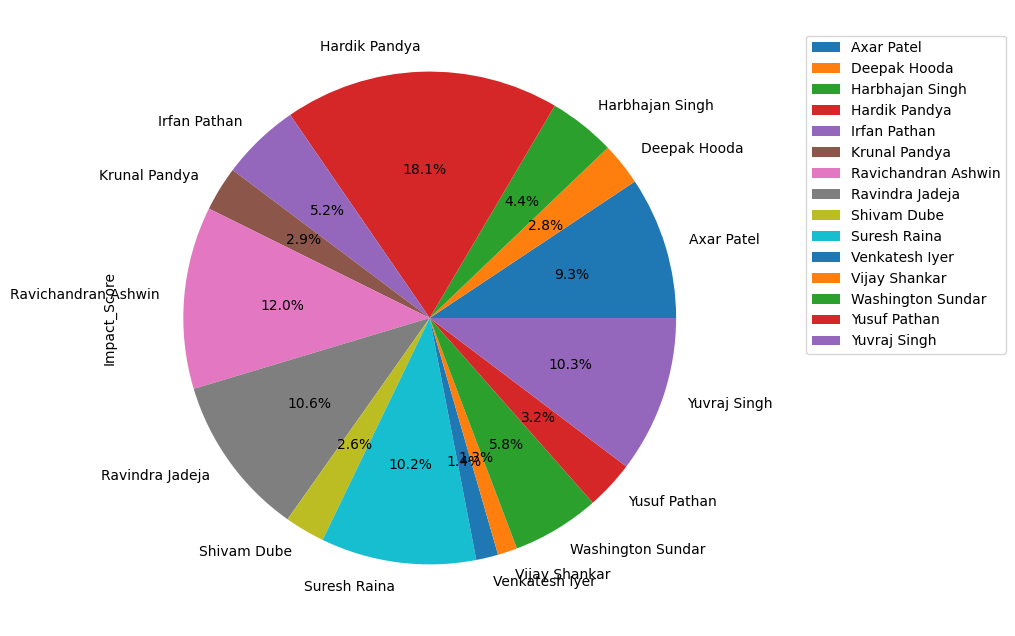

In [582]:
ax = all_rounders.plot(kind='pie',y='Impact_Score',legend=True, autopct='%1.1f%%',figsize=(8,8))
ax.legend(loc='center left',bbox_to_anchor=(1.1, 0.7))

In [583]:
matches[matches['Match Venue (Country)']== 'India'].groupby(['Match Venue (Country)','Match Venue (City)'])['Match Venue (Stadium)'].value_counts().reset_index(name='No. Matchs').head(20)

,Match Venue (Country),Match Venue (City),Match Venue (Stadium),No. Matchs
0,India,Ahmedabad,Narendra Modi Stadium,6
1,India,Ahmedabad,Sardar Patel Stadium,1
2,India,Bengaluru,M Chinnaswamy Stadium,10
3,India,Chandigarh,Punjab Cricket Association IS Bindra Stadium,5
4,India,Chandigarh,Punjab Cricket Association Stadium,1
5,India,Chennai,MA Chidambaram Stadium,2
6,India,Cuttack,Barabati Stadium,3
7,India,Dehra Dun,Rajiv Gandhi International Cricket Stadium,6
8,India,Delhi,Feroz Shah Kotla,5
9,India,Delhi,Arun Jaitley Stadium,2


In [584]:
matches[matches['Team1 Name']=='India'].groupby(['Team1 Name','Team2 Name'])['Toss Winner'].value_counts().reset_index(name='No. Toss Wins').head(30)

,Team1 Name,Team2 Name,Toss Winner,No. Toss Wins
0,India,Afghanistan,Afghanistan,3
1,India,Afghanistan,India,1
2,India,Australia,Australia,12
3,India,Australia,India,3
4,India,Bangladesh,Bangladesh,6
5,India,Bangladesh,India,1
6,India,England,England,12
7,India,England,India,4
8,India,Hong Kong,Hong Kong,1
9,India,Ireland,Ireland,3


In [585]:
bowler_merged.columns

Index(['Match ID', 'innings', 'team', 'opposition', 'bowler id', 'overs',
       'balls', 'maidens', 'conceded', 'wickets', 'economy', 'dots', 'fours',
       'sixes', 'wides', 'noballs', 'player_id', 'player_object_id',
       'player_name', 'dob', 'dod', 'gender', 'batting_style', 'bowling_style',
       'country_id', 'image_url', 'image_metadata', 'end_date', 'age'],
      dtype='object')

In [586]:
bowler_merged.sample(2)

,Match ID,innings,team,opposition,bowler id,overs,balls,maidens,conceded,wickets,...,dob,dod,gender,batting_style,bowling_style,country_id,image_url,image_metadata,end_date,age
12001,1202010,1,Vanuatu,Malaysia,57074.0,4.0,24.0,0.0,29.0,1,...,1991-09-27 00:00:00,0,M,right-hand bat,right-arm medium,216.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 243389, 'url': '/db/PICTURES/CMS/243300...",2026-02-07 10:16:22.125925,34.0
5155,875501,1,P.N.G.,Ireland,46828.0,1.0,6.0,0.0,13.0,0,...,1984-05-30 00:00:00,0,M,right-hand bat,right-arm medium,20.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 172857, 'url': '/db/PICTURES/CMS/172800...",2026-02-07 10:16:22.125925,41.0


In [587]:
batting_merged.head(1)

,Match ID,innings,team,batsman,runs,balls,fours,sixes,strikeRate,isOut,...,dob,dod,gender,batting_style,bowling_style,country_id,image_url,image_metadata,end_date,age
0,361657,1,Zimbabwe,10423.0,53,38.0,5.0,3.0,139,True,...,1983-08-09 00:00:00,0,M,right-hand bat,right-arm medium,9.0,"https://img1.hscicdn.com/image/upload/f_auto,t...","{'id': 203311, 'url': '/db/PICTURES/CMS/203300...",2026-02-07 10:16:22.125925,42.0


In [588]:
batting_merged['player_name']

0        Hamilton Masakadza
1             Cephas Zhuwao
2           Chamu Chibhabha
3             Tatenda Taibu
4               Salman Butt
                ...        
56352          Mahedi Hasan
56353          Taskin Ahmed
56354        Shoriful Islam
56355        Rishad Hossain
56356    Mohammad Saifuddin
Name: player_name, Length: 56357, dtype: object